# Pipeline de ETL com Dados Reais

## Sobre o pipeline
- **Dataset:** Autos de infração de trânsito em vias do Distrito Federal — consolidação de junho/2026
- **Fonte:** Portal de Dados Abertos do Governo de Brasília — https://www.dados.df.gov.br/pt/dataset#/infracoes-transito
- **Objetivo:** ler o arquivo bruto, tratar os problemas de qualidade encontrados, criar variáveis novas e agregações úteis e validar o resultado.

## 0. Configuração
Importa as bibliotecas e **localiza o CSV que já está no ambiente do Colab** (na raiz ou dentro de `sample_data/`), sem precisar de upload.

`REMOVER_DUPLICATAS = False` é uma decisão de análise, explicada na seção 3.2.

In [2]:
import re
import unicodedata
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


def achar_raiz_do_projeto():
    """Sobe a partir da pasta atual até achar a pasta que contém 'data/'."""
    atual = Path.cwd().resolve()
    for pasta in [atual, *atual.parents]:
        if (pasta / "data").is_dir():
            return pasta
    raise FileNotFoundError(
        "Pasta 'data/' não encontrada. Abra o notebook dentro do projeto "
        "(a pasta com data/, notebooks/ e output/)."
    )


RAIZ = achar_raiz_do_projeto()
PASTA_DADOS = RAIZ / "data"
PASTA_SAIDA = RAIZ / "output"
PASTA_SAIDA.mkdir(exist_ok=True)

encontrados = sorted(PASTA_DADOS.glob("*.csv"))
if not encontrados:
    raise FileNotFoundError(
        f"Nenhum CSV em {PASTA_DADOS}. Baixe o arquivo pela fonte "
        "indicada em data/README.md e salve nessa pasta."
    )
ARQUIVO = encontrados[0]
print("Arquivo encontrado:", ARQUIVO.name)

REMOVER_DUPLICATAS = False

Arquivo encontrado: Consolidação de dados de Autos de Infração do mês de Junho_2026.csv


## 1. Extração (Extract)
O arquivo usa `;` como separador e codificação UTF-8. Leio **todas as colunas como texto** (`dtype=str`) de propósito: assim o pandas não converte nada sozinho e eu controlo cada conversão de tipo na etapa de limpeza. `keep_default_na=False` evita que valores como "NA" virem ausentes sem eu perceber.

In [3]:
df_bruto = pd.read_csv(
    ARQUIVO,
    sep=";",
    encoding="utf-8",
    dtype=str,
    keep_default_na=False,
)

print(f"Linhas: {df_bruto.shape[0]:,} | Colunas: {df_bruto.shape[1]}")
df_bruto.head(10)

Linhas: 81,059 | Colunas: 10


,tipo_infracao,descricao,tipo_veiculo,cometimento,hora_cometimento,auinf_local_rodovia,auinf_local_km,auinf_local_referencia,auinf_local_complemento,grav_tipo
0,5908,Ultrapassar pelo acostamento,Automóvel,22/06/2026,17:22,DF 001,27,Sentido Crescente,,Gravíssima
1,5908,Ultrapassar pelo acostamento,Automóvel,12/06/2026,16:41,DF 290,29,Sentido Crescente,,Gravíssima
2,5819,Transitar com o veículo em acostamentos,Motocicleta,24/06/2026,13:20,DF 150,"6,7",Sentido Crescente,,Gravíssima
3,7579,"Recusar-se a ser submetido a teste, exame clín...",Automóvel,10/06/2026,20:11,DF 180,29,Sentido Crescente,em frente a embrapa,Gravíssima
4,5029,Dirigir veículo com CNH/PPD/ACC com suspensão ...,Automóvel,10/06/2026,19:09,"DF 004, VIA L4 SUL",12,Sentido Decrescente,,Gravíssima
5,5010,Dirigir veículo sem possuir CNH/PPD/ACC,Automóvel,10/06/2026,19:09,"DF 004, VIA L4 SUL",12,Sentido Decrescente,,Gravíssima
6,5703,Deixar de conservar o veículo na faixa a ele d...,Automóvel,24/06/2026,18:01,,,,via vicinal da DF 280,Média
7,5185,Deixar o condutor de usar o cinto segurança,Caminhonete,03/06/2026,10:45,DF 085,7,Sentido Decrescente,,Grave
8,7633,Dirigir veículo manuseando telefone celular,Caminhonete,03/06/2026,10:45,DF 085,7,Sentido Decrescente,,Gravíssima
9,6700,Conduzir veíc com vidro total/parcialmente cob...,Caminhonete,03/06/2026,10:45,DF 085,7,Sentido Decrescente,,Grave


## 2. Diagnóstico dos dados brutos
Antes de limpar, quero **medir** os problemas. Aqui olho ausentes, duplicatas e a variedade de valores nas colunas categóricas.

In [4]:
# Ausentes: célula vazia ou só com espaços
vazios = df_bruto.apply(lambda col: col.str.strip() == "").sum()
diagnostico = pd.DataFrame({
    "vazios": vazios,
    "% vazios": (vazios / len(df_bruto) * 100).round(1),
    "valores_unicos": df_bruto.nunique(),
})
display(diagnostico)

print("Linhas totalmente duplicadas:", df_bruto.duplicated().sum())
print("\nValores de tipo_veiculo (bruto):")
print(df_bruto["tipo_veiculo"].value_counts().head(12))
print("\nExemplos de auinf_local_rodovia (bruto):")
print(df_bruto["auinf_local_rodovia"].sample(8, random_state=1).tolist())

,vazios,% vazios,valores_unicos
tipo_infracao,0,0.0,143
descricao,0,0.0,195
tipo_veiculo,0,0.0,30
cometimento,0,0.0,30
hora_cometimento,0,0.0,1440
auinf_local_rodovia,164,0.2,483
auinf_local_km,55869,68.9,136
auinf_local_referencia,56201,69.3,6
auinf_local_complemento,78533,96.9,240
grav_tipo,1,0.0,5


Linhas totalmente duplicadas: 4431

Valores de tipo_veiculo (bruto):
tipo_veiculo
AUTOMOVEL       32647
Automóvel       17677
CAMINHONETE      6368
MOTOCICLETA      5895
CAMIONETA        3493
UTILITARIO       2781
Caminhonete      2495
CAMINHAO         2382
Motocicleta      1789
Camioneta        1321
SEMI-REBOQUE     1228
Caminhão          835
Name: count, dtype: int64

Exemplos de auinf_local_rodovia (bruto):
['RODOVIA DF-290 KM 26,4', 'RODOVIA DF-290 KM 27,5', 'DF 001', '128', 'DF-002 KM 6,8(ENTRADA BURACO TATU) SENTIDO SUL - DER632', 'RODOVIA DF -128, KM 0,4', 'RODOVIA DF-079 (EPVP), KM 2,7', 'DF-075(EPNB) Km 2,5 SENT. N.BAND / RIACHO FUNDO - DER097']


**Problemas encontrados**
1. `tipo_veiculo` escrito de formas diferentes (`AUTOMOVEL` × `Automóvel`).
2. `auinf_local_rodovia` com 400+ valores únicos: mistura de formatos (`DF 001`, `RODOVIA DF-150, KM 4,6`, `001`...), com km e sentido embutidos no texto.
3. `auinf_local_km` e `auinf_local_referencia` muito vazias; `auinf_local_km` usa vírgula decimal.
4. Linhas idênticas em todas as colunas (mantidas por decisão de análise).
5. Mesmo código de infração com descrições diferentes.
6. Data e hora como texto; 1 registro sem gravidade.

## 3. Limpeza (Clean)
Cada bloco trata um problema. Sempre crio **colunas novas** e mantenho as originais até o final, para poder comparar antes e depois.

### 3.1 Espaços em branco e valores vazios
Remove espaços das pontas e transforma texto vazio em ausente (`NA`) de verdade.

In [5]:
df = df_bruto.copy()
df = df.apply(lambda col: col.str.strip())
df = df.replace(r"^\s*$", pd.NA, regex=True)
print("Ausentes por coluna:")
print(df.isna().sum())

Ausentes por coluna:
tipo_infracao                  0
descricao                      0
tipo_veiculo                   0
cometimento                    0
hora_cometimento               0
auinf_local_rodovia          164
auinf_local_km             55869
auinf_local_referencia     56201
auinf_local_complemento    78533
grav_tipo                      1
dtype: int64


### 3.2 Duplicatas
O arquivo **não tem coluna de identificação** do auto (nem placa). Existem linhas idênticas em todas as colunas, mas cada linha representa **um auto de infração**, e duas linhas iguais podem ser infrações de **veículos diferentes** no mesmo minuto e local (por exemplo, em pontos com fiscalização eletrônica e muito movimento). Como não há evidência de que sejam registros repetidos, **decidi manter todas as linhas** para não subestimar o número de infrações. Meço o impacto apenas para documentar a decisão; a remoção continua disponível com `REMOVER_DUPLICATAS = True`.

In [6]:
linhas_antes = len(df)
n_duplicadas = df.duplicated().sum()

if REMOVER_DUPLICATAS:
    df = df.drop_duplicates().reset_index(drop=True)

n_removidas = n_duplicadas if REMOVER_DUPLICATAS else 0

print(f"Linhas idênticas em todas as colunas: {n_duplicadas:,} ({n_duplicadas / linhas_antes:.1%} das linhas)")
print("Ação:", "removidas" if REMOVER_DUPLICATAS else "MANTIDAS (cada linha é um auto de infração)")
print(f"Linhas antes: {linhas_antes:,} | depois: {len(df):,}")

Linhas idênticas em todas as colunas: 4,431 (5.5% das linhas)
Ação: MANTIDAS (cada linha é um auto de infração)
Linhas antes: 81,059 | depois: 81,059


### 3.3 Tipo de veículo
Padronizo caixa e acentos (tudo em maiúsculas, sem acento). **Não** junto `CAMIONETA` com `CAMINHONETE`: no Código de Trânsito Brasileiro são categorias diferentes.

In [7]:
def sem_acento(texto):
    """Remove acentos: 'Automóvel' -> 'Automovel'."""
    return unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("ascii")

df["tipo_veiculo"] = df["tipo_veiculo"].map(lambda x: sem_acento(x).upper() if pd.notna(x) else x)

print(df["tipo_veiculo"].nunique(), "categorias de veículo após padronização")
df["tipo_veiculo"].value_counts()

16 categorias de veículo após padronização


tipo_veiculo
AUTOMOVEL          50324
CAMINHONETE         8863
MOTOCICLETA         7684
CAMIONETA           4814
UTILITARIO          3537
CAMINHAO            3217
SEMI-REBOQUE        1262
MOTONETA             487
CAMINHAO TRATOR      332
ONIBUS               179
MICROONIBUS          169
REBOQUE              161
CICLOMOTOR            20
MOTOR-CASA             5
TRICICLO               4
TR MISTO               1
Name: count, dtype: int64

### 3.4 Rodovia e quilômetro
A coluna de rodovia mistura vários formatos. Uso expressão regular para extrair o código padronizado (`DF-075`, `BR-020`...). Regras:
- texto com `DF`/`BR` + número → `DF-075`
- só número (ex.: `075`) → assume `DF-075` (as demais linhas indicam que são rodovias distritais)
- vazio → `NÃO INFORMADA`
- qualquer outro (túneis, vias de ligação) → `OUTRAS VIAS`

O km, quando a coluna própria está vazia, é recuperado do texto (`... KM 4,6`). Valores de km impossíveis (acima de 200, erro de digitação na origem) viram ausentes.

In [8]:
def padronizar_rodovia(texto):
    if pd.isna(texto):
        return "NÃO INFORMADA"
    achou = re.search(r"\b(DF|BR)\s*-?\s*0*(\d{1,3})\b", texto, flags=re.IGNORECASE)
    if achou:
        return f"{achou.group(1).upper()}-{int(achou.group(2)):03d}"
    so_numero = re.fullmatch(r"0*(\d{1,3})", texto)
    if so_numero:
        return f"DF-{int(so_numero.group(1)):03d}"
    return "OUTRAS VIAS"

df["rodovia_padrao"] = df["auinf_local_rodovia"].map(padronizar_rodovia)

# Km: usa a coluna própria; se vazia, tenta extrair do texto da rodovia
km_coluna = pd.to_numeric(df["auinf_local_km"].str.replace(",", ".", regex=False), errors="coerce")
km_texto = pd.to_numeric(
    df["auinf_local_rodovia"].str.extract(r"(?i)km\s*(\d+(?:[.,]\d+)?)")[0].str.replace(",", ".", regex=False),
    errors="coerce",
)
df["km"] = km_coluna.fillna(km_texto)

# Km impossível (erro de digitação na origem, ex.: 72056): trata como ausente
KM_MAXIMO = 200
km_invalidos = (df["km"] > KM_MAXIMO).sum()
df.loc[df["km"] > KM_MAXIMO, "km"] = pd.NA
df["km"] = df["km"].astype(float)
print(f"Km acima de {KM_MAXIMO} (inválidos) convertidos para ausente: {km_invalidos}")

print(f"Valores únicos de rodovia: {df['auinf_local_rodovia'].nunique()} (antes) -> {df['rodovia_padrao'].nunique()} (depois)")
print(f"Km ausente: {km_coluna.isna().sum():,} (antes) -> {df['km'].isna().sum():,} (depois)")
df["rodovia_padrao"].value_counts().head(10)

Km acima de 200 (inválidos) convertidos para ausente: 1
Valores únicos de rodovia: 482 (antes) -> 68 (depois)
Km ausente: 55,869 (antes) -> 656 (depois)


rodovia_padrao
DF-075    19713
DF-001    14808
DF-003     8206
DF-085     5361
DF-002     3405
DF-005     2996
DF-079     2730
DF-025     2634
DF-150     2596
DF-004     2316
Name: count, dtype: int64

### 3.5 Sentido da via
Padroniza as variações (`Sentido Crescente`, `CRESCENTE`, `SENTIDO DECRESCENTE`...). Atenção à ordem do teste: `DECRESCENTE` contém a palavra `CRESCENTE`.

In [9]:
def padronizar_sentido(texto):
    if pd.isna(texto):
        return "NÃO INFORMADO"
    t = sem_acento(texto).upper()
    if "DECRESCENTE" in t:      # testar primeiro (contém "CRESCENTE")
        return "DECRESCENTE"
    if "CRESCENTE" in t:
        return "CRESCENTE"
    return "OUTRO"

df["sentido"] = df["auinf_local_referencia"].map(padronizar_sentido)
df["sentido"].value_counts()

sentido
NÃO INFORMADO    56201
CRESCENTE        14925
DECRESCENTE       9933
Name: count, dtype: int64

### 3.6 Data e hora
Converte texto para tipos de data/hora reais. `errors="coerce"` transforma valores inválidos em `NaT`, que a validação depois detecta.

In [10]:
df["data_hora"] = pd.to_datetime(
    df["cometimento"] + " " + df["hora_cometimento"],
    format="%d/%m/%Y %H:%M",
    errors="coerce",
)
print("Datas/horas inválidas:", df["data_hora"].isna().sum())
print("Período:", df["data_hora"].min(), "até", df["data_hora"].max())

Datas/horas inválidas: 0
Período: 2026-06-01 00:00:00 até 2026-06-30 22:54:00


### 3.7 Descrição e gravidade por código de infração
- **Descrição:** o mesmo código aparece com textos diferentes. Uso a descrição **mais frequente** de cada código como padrão.
- **Gravidade:** a gravidade é uma propriedade do código da infração. O único registro sem gravidade é preenchido com a gravidade mais comum do seu próprio código, quando existe outro registro com o mesmo código. Se o código só aparece uma vez (caso do código 7498), o registro **é mantido** como `NÃO INFORMADA` em vez de ser descartado: perder uma infração real seria pior do que ter um rótulo faltando.

In [11]:
# Descrição padrão = a mais frequente para cada código
desc_padrao = df.groupby("tipo_infracao")["descricao"].agg(lambda s: s.mode().iloc[0])
df["descricao_padrao"] = df["tipo_infracao"].map(desc_padrao)
print(f"Descrições distintas: {df['descricao'].nunique()} -> {df['descricao_padrao'].nunique()}")

# Gravidade: preenche ausente com a gravidade típica do mesmo código
grav_por_codigo = (
    df.dropna(subset=["grav_tipo"])
      .groupby("tipo_infracao")["grav_tipo"]
      .agg(lambda s: s.mode().iloc[0])
)
ausentes_grav = df["grav_tipo"].isna().sum()
df["gravidade"] = df["grav_tipo"].fillna(df["tipo_infracao"].map(grav_por_codigo)).fillna("NÃO INFORMADA")
print(f"Gravidade ausente: {ausentes_grav} -> {(df['gravidade'] == 'NÃO INFORMADA').sum()} depois do preenchimento")

Descrições distintas: 195 -> 143
Gravidade ausente: 1 -> 1 depois do preenchimento


## 4. Transformação (Transform)
Crio variáveis que **agregam valor** ao dado original: dia da semana, período do dia, fim de semana e um grupo de infração mais fácil de analisar do que 195 descrições. Depois faço agregações.

In [12]:
DIAS = ["segunda", "terça", "quarta", "quinta", "sexta", "sábado", "domingo"]

df["data"] = df["data_hora"].dt.date
df["hora"] = df["data_hora"].dt.hour
df["dia_semana"] = df["data_hora"].dt.dayofweek.map(lambda i: DIAS[i] if pd.notna(i) else pd.NA)
df["fim_de_semana"] = df["data_hora"].dt.dayofweek >= 5

# Período do dia a partir da hora
df["periodo_dia"] = pd.cut(
    df["hora"],
    bins=[-1, 5, 11, 17, 23],
    labels=["Madrugada (0-5h)", "Manhã (6-11h)", "Tarde (12-17h)", "Noite (18-23h)"],
)

def agrupar_infracao(descricao):
    """Agrupa as descrições em categorias temáticas por palavra-chave."""
    d = descricao.lower()
    if "velocidade" in d:
        return "Velocidade"
    if "exclusiv" in d:
        return "Faixa/via exclusiva"
    if "celular" in d:
        return "Celular ao volante"
    if "semáforo" in d or "semaforo" in d or "sinal vermelho" in d:
        return "Sinal vermelho"
    if "cinto" in d:
        return "Cinto de segurança"
    if "indicar" in d or "sinalização de manobra" in d:
        return "Falta de sinalização de manobra"
    return "Outras"

df["grupo_infracao"] = df["descricao_padrao"].map(agrupar_infracao)

df[["data_hora", "dia_semana", "periodo_dia", "fim_de_semana", "grupo_infracao"]].head()

,data_hora,dia_semana,periodo_dia,fim_de_semana,grupo_infracao
0,2026-06-22 17:22:00,segunda,Tarde (12-17h),False,Outras
1,2026-06-12 16:41:00,sexta,Tarde (12-17h),False,Outras
2,2026-06-24 13:20:00,quarta,Tarde (12-17h),False,Outras
3,2026-06-10 20:11:00,quarta,Noite (18-23h),False,Outras
4,2026-06-10 19:09:00,quarta,Noite (18-23h),False,Outras


In [13]:
# Agregação 1: infrações por rodovia, com participação de gravíssimas
por_rodovia = (
    df.groupby("rodovia_padrao")
      .agg(total=("data_hora", "size"),
           gravissimas=("gravidade", lambda s: (s == "Gravíssima").sum()))
      .sort_values("total", ascending=False)
)
por_rodovia["% do total"] = (por_rodovia["total"] / por_rodovia["total"].sum() * 100).round(1)
por_rodovia["% gravíssimas"] = (por_rodovia["gravissimas"] / por_rodovia["total"] * 100).round(1)

# Agregação 2: grupo de infração x período do dia
grupo_periodo = pd.crosstab(df["grupo_infracao"], df["periodo_dia"], margins=True, margins_name="Total")

# Agregação 3: infrações por hora do dia
por_hora = df.groupby("hora").size()

display(por_rodovia.head(10))
display(grupo_periodo)

,total,gravissimas,% do total,% gravíssimas
rodovia_padrao,,,,
DF-075,19713,1133,24.3,5.7
DF-001,14808,3427,18.3,23.1
DF-003,8206,2009,10.1,24.5
DF-085,5361,549,6.6,10.2
DF-002,3405,92,4.2,2.7
DF-005,2996,74,3.7,2.5
DF-079,2730,61,3.4,2.2
DF-025,2634,394,3.2,15.0
DF-150,2596,74,3.2,2.9


periodo_dia,Madrugada (0-5h),Manhã (6-11h),Tarde (12-17h),Noite (18-23h),Total
grupo_infracao,,,,,
Celular ao volante,8,1006,1035,175,2224
Cinto de segurança,3,929,822,61,1815
Faixa/via exclusiva,209,7591,9116,2251,19167
Falta de sinalização de manobra,3,755,2542,303,3603
Outras,594,3655,4220,3422,11891
Sinal vermelho,292,396,384,477,1549
Velocidade,5035,11844,14320,9611,40810
Total,6144,26176,32439,16300,81059


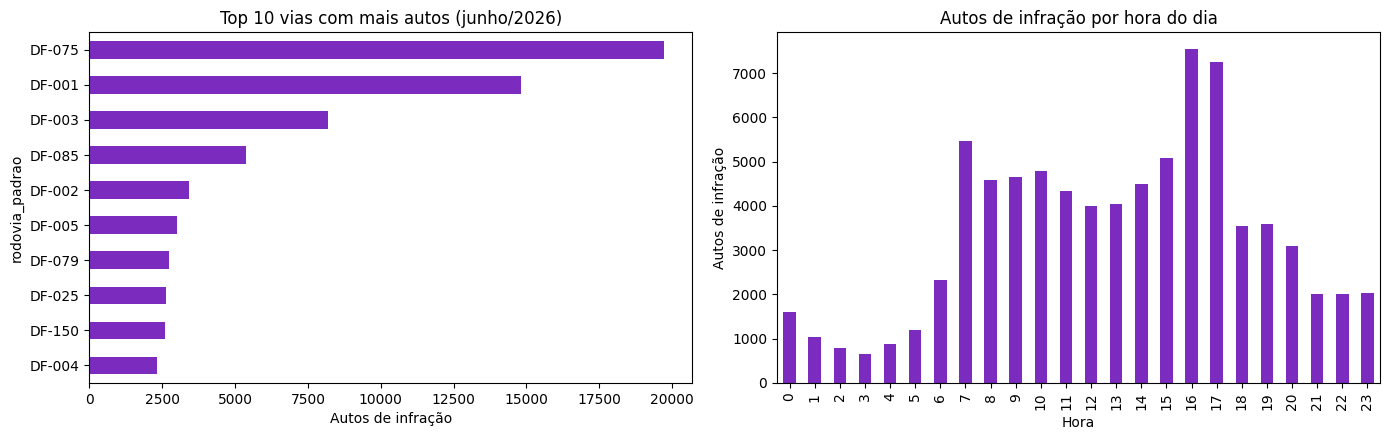

In [14]:
fig, eixos = plt.subplots(1, 2, figsize=(14, 4.5))

por_rodovia["total"].head(10).sort_values().plot.barh(ax=eixos[0], color="#7B2CBF")
eixos[0].set_title("Top 10 vias com mais autos (junho/2026)")
eixos[0].set_xlabel("Autos de infração")

por_hora.plot.bar(ax=eixos[1], color="#7B2CBF")
eixos[1].set_title("Autos de infração por hora do dia")
eixos[1].set_xlabel("Hora")
eixos[1].set_ylabel("Autos de infração")

plt.tight_layout()
plt.show()

## 5. Validação
Checagens simples para confirmar que o resultado faz sentido. Cada uma imprime ✅ ou ❌ e, no final, o notebook falha se alguma checagem quebrar.

In [15]:
resultados = []

def checar(descricao, condicao):
    resultados.append(bool(condicao))
    print(("✅" if condicao else "❌"), descricao)

# 1. Sem datas inválidas
checar("Nenhuma data/hora inválida", df["data_hora"].notna().all())

# 2. Todas as datas dentro de junho/2026 (o arquivo é o consolidado do mês)
checar("Todas as datas estão entre 01/06/2026 e 30/06/2026",
       df["data_hora"].between("2026-06-01", "2026-06-30 23:59:59").all())

# 3. Hora plausível
checar("Horas entre 0 e 23", df["hora"].between(0, 23).all())

# 4. Gravidade só com valores esperados (aceita 'NÃO INFORMADA' residual, mas mede quantos)
gravidades_validas = {"Leve", "Média", "Grave", "Gravíssima", "NÃO INFORMADA"}
checar("Gravidade só tem as 4 categorias oficiais (+ 'NÃO INFORMADA')",
       set(df["gravidade"].unique()) <= gravidades_validas)
n_sem_grav = (df["gravidade"] == "NÃO INFORMADA").sum()
checar(f"Gravidade não informada é residual (<0,1% das linhas): {n_sem_grav} registro(s)",
       n_sem_grav / len(df) < 0.001)

# 5. Km em intervalo plausível para rodovias do DF (ignorando ausentes)
km_ok = df["km"].dropna()
checar(f"Km entre 0 e 200 (mín={km_ok.min()}, máx={km_ok.max()})", km_ok.between(0, 200).all())

# 6. Contagem de registros compatível com o esperado
esperado = len(df_bruto) - n_removidas
checar(f"Nº de linhas ({len(df):,}) = bruto ({len(df_bruto):,}) - removidas ({n_removidas:,})", len(df) == esperado)

# 7. As agregações preservam o total
checar("Soma por rodovia = total de linhas", por_rodovia["total"].sum() == len(df))
checar("Tabela grupo x período = total de linhas", grupo_periodo.loc["Total", "Total"] == len(df))

# 8. Um código de infração ficou com uma única descrição padrão
checar("Cada código de infração tem 1 descrição padrão", df.groupby("tipo_infracao")["descricao_padrao"].nunique().max() == 1)

assert all(resultados), "Alguma validação falhou: revise as etapas de limpeza."
print("\nTodas as validações passaram.")

✅ Nenhuma data/hora inválida
✅ Todas as datas estão entre 01/06/2026 e 30/06/2026
✅ Horas entre 0 e 23
✅ Gravidade só tem as 4 categorias oficiais (+ 'NÃO INFORMADA')
✅ Gravidade não informada é residual (<0,1% das linhas): 1 registro(s)
✅ Km entre 0 e 200 (mín=0.0, máx=178.0)
✅ Nº de linhas (81,059) = bruto (81,059) - removidas (0)
✅ Soma por rodovia = total de linhas
✅ Tabela grupo x período = total de linhas
✅ Cada código de infração tem 1 descrição padrão

Todas as validações passaram.


## 6. Carga (Load)
Salva o dataset tratado e a tabela agregada em CSV (separador `;` e UTF-8 com BOM, para abrir corretamente no Excel).

In [16]:
colunas_finais = [
    "data_hora", "data", "hora", "dia_semana", "periodo_dia", "fim_de_semana",
    "tipo_infracao", "descricao_padrao", "grupo_infracao", "gravidade",
    "tipo_veiculo", "rodovia_padrao", "km", "sentido",
]

df[colunas_finais].to_csv("infracoes_tratadas_2026_06.csv", sep=";", index=False, encoding="utf-8-sig")
por_rodovia.to_csv("resumo_por_rodovia_2026_06.csv", sep=";", encoding="utf-8-sig")

print(f"Arquivos salvos: infracoes_tratadas_2026_06.csv ({len(df):,} linhas) e resumo_por_rodovia_2026_06.csv")

Arquivos salvos: infracoes_tratadas_2026_06.csv (81,059 linhas) e resumo_por_rodovia_2026_06.csv


## Decisões e limitações (resumo)
- **Linhas idênticas (~5,5%):** mantidas, pois cada linha é um auto e podem ser veículos diferentes no mesmo minuto e local. Sem ID do auto ou placa não é possível provar isso com os dados; é uma premissa, e a decisão é ajustável.
- **Km inválido:** um registro com km 72056 (impossível) foi tratado como ausente; o km ausente cai de ~69% para ~1% depois de recuperar o valor a partir do texto da rodovia.
- **Rodovia só com número:** assumi que é rodovia distrital (`DF-`), com base no padrão das demais linhas.
- **`OUTRAS VIAS`:** túneis e vias de ligação nomeadas ficaram agrupados; poderiam ser detalhados numa próxima versão.
- **Um único mês de dados:** conclusões sobre sazonalidade não são possíveis com este recorte.